<a href="https://colab.research.google.com/github/LeonardooAlves/WM9G1-BDAI/blob/main/Week%203/3_NLP_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis with TextBlob and NLTK VADER

## What is Sentiment Analysis?

**Sentiment analysis** (also called *opinion mining*) is the use of Natural Language Processing (NLP) to automatically identify and quantify the emotional tone of a piece of text. The goal is to determine whether a document, sentence, or phrase expresses a **positive**, **negative**, or **neutral** opinion.

### Why does sentiment analysis matter for business?

Every day, customers leave traces of their opinions across review platforms, social media, support tickets, and surveys. Manually reading thousands of reviews to gauge customer satisfaction is impractical. Sentiment analysis enables organisations to:

- **Monitor brand health** at scale — track whether public opinion is trending positive or negative over time
- **Prioritise customer complaints** — automatically flag highly negative reviews for urgent follow-up
- **Benchmark against competitors** — compare sentiment scores across products or services
- **Validate product changes** — measure whether a new feature improved customer sentiment
- **Enrich structured data** — convert unstructured text into a numerical score that can be combined with ratings, dates, and demographics for deeper analysis

## The Two Approaches in This Notebook

We will use two lexicon-based sentiment analysis tools:

| Tool | Library | Scores Produced | Best For |
|------|---------|----------------|----------|
| **TextBlob** | `textblob` | Polarity [-1, 1], Subjectivity [0, 1] | General text, quick analysis |
| **VADER** | `nltk` | Compound [-1, 1], Positive, Neutral, Negative [0, 1] | Social media, short informal text |

### Lexicon-based vs. Machine Learning sentiment analysis

Both tools are **lexicon-based** — they rely on a pre-built dictionary of words labelled with sentiment scores, and compute the sentiment of a document by aggregating scores across its words. This approach:

- Requires no labelled training data  
- Is fast and interpretable  
- Works out of the box on any domain  
- Can struggle with sarcasm, irony, and highly domain-specific language  
- Does not learn from your specific dataset  

Machine learning approaches (e.g. fine-tuning BERT on labelled reviews) can outperform lexicon methods on specific domains, but require labelled data. For exploratory analysis of customer reviews without labelled ground truth, lexicon methods are an excellent starting point.

## Dataset

In Section 2, we apply batch sentiment analysis to a real dataset of app reviews. The `target_column` variable is set to `'content'`, the column containing the review text. This variable can be changed to point to any text column in your own dataset.


---
# 1. Sentiment Analysis of a Single Text

Before processing large datasets, it is essential to understand what each tool actually measures and how to interpret its output. In this section, we run both TextBlob and VADER on a single example sentence so you can inspect the scores in detail.


In [1]:
# Here we input a sentence as an example
# Click the play button one the left in the each cell to run the code.
sentence = "The show is great and I would like to watch again"

The variable `sentence` holds our test input. This is a clearly positive statement. We expect both tools to assign a positive sentiment score. Try modifying this sentence later to test different emotional tones.


## 1.1 TextBlob Sentiment

### How TextBlob works

TextBlob calculates sentiment by looking up each word in the **Pattern lexicon**, a sentiment dictionary built into the library. For each word that appears in the lexicon, TextBlob retrieves two values:

- **Polarity:** How positive or negative the word is, on a scale from -1.0 to +1.0
  - `+1.0` = maximally positive (e.g. *excellent*, *amazing*)
  - `-1.0` = maximally negative (e.g. *terrible*, *awful*)
  - `0.0` = neutral (e.g. *the*, *and*, words not in the lexicon)
- **Subjectivity:** How opinion-based vs fact-based the word is, from 0.0 to 1.0
  - `0.0` = objective / factual (e.g. *the flight departed at 9am*)
  - `1.0` = subjective / opinion (e.g. *the crew was incredibly rude*)

The sentence-level score is computed as the **average** of the word-level scores for all recognised words. TextBlob also handles valence shifters (e.g. *not good* will reduce the polarity of *good*).

### Score interpretation guide

| Polarity Range | Interpretation |
|----------------|----------------|
| 0.5 to 1.0 | Strongly positive |
| 0.1 to 0.5 | Mildly positive |
| -0.1 to 0.1 | Neutral |
| -0.5 to -0.1 | Mildly negative |
| -1.0 to -0.5 | Strongly negative |

| Subjectivity Range | Interpretation |
|--------------------|----------------|
| 0.0 to 0.3 | Largely factual / objective |
| 0.3 to 0.6 | Mixed fact and opinion |
| 0.6 to 1.0 | Strongly opinion-based |


In [2]:
from textblob import TextBlob
# import the TextBlob package.

In [3]:
# TextBlob().sentiment is the method used to calculate the score. put the sentence/text into the bracket
# After you run the code you will be able to see the scores.
TextBlob(sentence).sentiment

# the polarity is between [-1,1]. while closer to -1 is more negative, closer to 1 is more positive.

Sentiment(polarity=0.8, subjectivity=0.75)

Note that TextBlob returns a named tuple `Sentiment(polarity, subjectivity)`. For our example sentence *"The show is great and I would like to watch again"*:

- **Polarity** should be positive (likely around 0.8), reflecting words like *great*
- **Subjectivity** will be moderate to high, as the sentence expresses a personal opinion (*I would like*) and an evaluative adjective (*great*)

Notice that TextBlob provides **two dimensions** of information — polarity and subjectivity. This is unique to TextBlob and can be very useful: a highly subjective review with low polarity might indicate a strongly-worded but balanced opinion, while a low-subjectivity statement with negative polarity might indicate a factual complaint (e.g. *'The flight was 3 hours late'*).


## 1.2 NLTK VADER Sentiment

### How VADER works

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) was developed by Hutto & Gilbert (2014) specifically for **social media text**: short, informal, emoji-rich, and slang-heavy content. It has been validated on tweets, forum posts, and app reviews.

VADER's lexicon contains over 7,500 words and emoticons, each rated by human annotators. Beyond simple word lookup, VADER applies five grammatical and typographical rules:

1. **Punctuation:** `!!!` amplifies sentiment intensity
2. **Capitalisation:** `GREAT` is more intense than `great`
3. **Degree modifiers:** *extremely good* is more positive than *good*; *barely good* is less so
4. **Contrastive conjunctions:** *'but'* shifts sentiment — *'The food was good but the service was terrible'* weights the negative clause more heavily
5. **Negation:** *'not good'*, *'never helpful'* flip the polarity of adjacent sentiment words

### VADER's four scores

| Score | Range | Meaning |
|-------|-------|----------|
| **pos** | 0.0 – 1.0 | Proportion of text that is positive |
| **neu** | 0.0 – 1.0 | Proportion of text that is neutral |
| **neg** | 0.0 – 1.0 | Proportion of text that is negative |
| **compound** | -1.0 – 1.0 | Overall sentiment score (most commonly used) |

Note that `pos + neu + neg = 1.0`, they are proportions that partition all the text.

### Classification thresholds (compound score)

The standard VADER classification rule is:

```
compound >= +0.05  →  Positive
compound <= -0.05  →  Negative
-0.05 < compound < +0.05  →  Neutral
```

These thresholds were determined empirically by the VADER authors. You can adjust them based on your domain. For example, stricter business requirements might use ±0.2 to be more confident in positive/negative labels.

### Why ±0.05 and not 0?

A compound of exactly 0 would require perfectly balanced positive and negative content. In practice, most real-world text leans slightly one way or the other even if the overall tone is neutral. The ±0.05 buffer accounts for this.


In [4]:
# This is another python package for sentiment analysis, and it's called nltk vader. SentimenIntensityAnalyzer() is the function.
import nltk
nltk.download('vader_lexicon')

# Before run the function, you need to import the nltk package and download the vader_lexicon first.

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

NLTK downloads the VADER sentiment lexicon file (`vader_lexicon.zip`) to your local NLTK data directory. This only needs to happen once per environment and subsequent runs will print `[nltk_data] Package vader_lexicon is already up-to-date`. The lexicon file contains ~7,500 words with their mean sentiment rating and standard deviation across human annotators.


In [5]:
# Now it's all set up and you need to import the sentiment_intensity_analyzer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

In [6]:
# Here you can use the analyzer function to calculate the score of the sentence.
# After you run the function you should be able to see 4 scores.
sid.polarity_scores(sentence)

# same as textblob, the compound score is between -1 and 1, and closer to 1 the higher positivity of the text.

{'neg': 0.0, 'neu': 0.548, 'pos': 0.452, 'compound': 0.765}

The above VADER analysis returns a dictionary with four keys. For our example sentence *"The show is great and I would like to watch again"*:

- **`pos`**: Should be the largest non-neutral value, driven by the word *great*
- **`neu`**: Will be high — most words (*the*, *show*, *is*, *and*, *I*, *would*, *like*, *to*, *watch*, *again*) are sentiment-neutral
- **`neg`**: Should be near 0 — no negative words in this sentence
- **`compound`**: Should be clearly positive (above +0.05)

**Comparing TextBlob and VADER on this sentence:** Both should agree that the sentiment is positive. TextBlob additionally tells us the text is subjective. VADER additionally gives us a breakdown of what proportion of the text is positive, neutral, and negative.

---

### Exercise 1 — Single Text Scoring

Run the cells above with each of the following sentences and record the TextBlob polarity, TextBlob subjectivity, and VADER compound scores. Which tool seems more sensitive? Which gives more nuanced scores?

1. `"The service was absolutely terrible and I will never fly with them again."`
2. `"The flight departed on time. The aircraft was an A320."`  *(factual statement)*
3. `"The food was not bad but the seat was uncomfortable."`  *(mixed sentiment with negation)*
4. `"WORST EXPERIENCE EVER!!!"`  *(capitalisation + punctuation)*
5. `"I guess it was okay, nothing special."`  *(mildly negative/neutral)*

After testing, reflect on:
- For sentence 2 (factual), is the subjectivity score from TextBlob what you expected?
- For sentence 3 (mixed), does VADER's `neg` score reflect the negative component even though the compound is moderate?
- For sentence 4, does VADER's rule for capitalisation and punctuation make it score more negatively than TextBlob?


---
# 2. Sentiment Analysis of Batch Text

Analysing a single sentence is useful for understanding how the tools work, but the real value of sentiment analysis comes from applying it at scale — across hundreds or thousands of documents simultaneously.

In this section we:
1. Upload a CSV file of real app reviews
2. Apply TextBlob to generate polarity and subjectivity scores for every review
3. Apply VADER to generate compound, positive, neutral, and negative scores
4. Classify each review as Positive, Neutral, or Negative
5. Visualise the sentiment distribution
6. Export the enriched dataset

The dataset used here is a collection of **Any.do app reviews** from the Google Play Store. Each row is one user review with columns including `content` (the review text), `score` (the star rating), and `at` (the date).


## 2.1 Batch Sentiment Analysis with TextBlob

We use pandas `apply()` with a lambda function to run TextBlob on every row in the DataFrame efficiently. This is much faster than a manual `for` loop because pandas can vectorise the operation internally.

### Pipeline for this section

```
Upload CSV → Read into DataFrame → Drop nulls → Apply TextBlob → Classify → Visualise → Export
```


### Upload Widget

Running this cell opens a file picker. Select your CSV file from your local machine. The file is temporarily stored in the Colab session's virtual filesystem. **Important:** if you disconnect from Colab or start a new session, you will need to re-upload the file.

> **💡 Tip:** You can also load files directly from Google Drive to avoid re-uploading:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> df = pd.read_csv('/content/drive/MyDrive/your_file.csv')
> ```


Alternatively, just upload it manually by clicking on the `Files` on the sidebar and pressing `Upload to session storage`.

In [7]:
# Except for doing sentiment analysis for one single sentence, it's also available for you to import a dataframe and do the sentiment analysis for the whole batch.
from google.colab import files
uploaded = files.upload()
# once you run this code, it will prompt you to select a file. You just need to "Choose a file" (any file you want to do sentiment analysis) from your laptop.

Saving Anydo_review_new.csv to Anydo_review_new (1).csv


In [8]:
# once you upload the data to the cloud, you can read the data into dataframe. Remember, if you close the notebook or disconnect, you need to upload the file (run the code above) again before you read data.

import pandas as pd
data_path = 'Anydo_review_new.csv' # change the csv file name to your file name that you uploaded
df = pd.read_csv(data_path)
df.head()

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at
0,gp:AOqpTOEcWS_b8b4P2gClKovxXAPg3il0AD0ZnGw9RxY...,Unable to use it as it won't work with my Goog...,1,13,5.7.0.20,11/01/2021 01:12
1,gp:AOqpTOEidRmDaHGYPZW21SVfBkeqTruAzg7LAmCPL2_...,I downloaded this because of the cross platfor...,1,81,5.7.0.20,22/12/2020 18:31
2,gp:AOqpTOEJfVU5Os7_8CNOu_mpy2AlDz8kFxEFMeBMnxC...,I am starting to hate this app! Every time the...,1,67,5.7.0.10,02/12/2020 15:52
3,gp:AOqpTOFSPaoOVarqwKF86e7-TPUyV6BanSXKRNFGb6G...,"Liked Any.do at first, enough that I even sign...",1,102,5.7.0.10,22/11/2020 23:42
4,gp:AOqpTOEmghRiCCy0_FYbWBSoRm2ff2hzFTbEjgQ9svu...,They made me sign up for premium just to have ...,1,2,5.7.0.20,31/12/2020 01:49


`df.head()` displays the first 5 rows of the loaded DataFrame. Check that:
- The column containing review text is visible (here: `content`)
- The data has loaded correctly: no truncation, encoding errors, or empty rows at the top
- Column names match what you will reference in `target_column` below

The dataset should have at least the columns: `content` (review text), `score` (star rating 1–5), and `at` (review date). These can be used later to cross-validate sentiment scores against ratings.


In [9]:
# set the target column to the review column

target_column = 'content'

`target_column = 'content'` tells the rest of the pipeline which column to run sentiment analysis on. If your dataset uses a different column name (e.g. `'review_text'`, `'body'`, `'feedback'`), change this single variable and the entire pipeline will update automatically — no need to hunt through multiple cells.


Before any analysis, removing possible missing values.

In [10]:
# you might need to do some text cleaning before sentiment analysis. One basic requirement for running the sentiment analysis function, you need to make sure the target column has no null values.
df = df.dropna(subset = [target_column]) # Here I just delete the rows if the target column is null (that is, if values are missing)

Both TextBlob and VADER will throw an error if they encounter a `NaN` (null) value — they expect a string input. `df.dropna(subset=[target_column])` removes any rows where the review text is missing before we begin.

**Alternative approaches to missing values:**
- `df[target_column].fillna('')` — replace nulls with empty strings (VADER will score them as neutral)
- `df[target_column].fillna('no review')` — replace with a placeholder string

For this tutorial, simply dropping null rows is safest. Check how many rows were removed with `print(f'Rows removed: {original_length - len(df)}')`.


In [11]:
from textblob import TextBlob
import numpy as np
df['Polarity'] = df[target_column].apply(lambda review: TextBlob(str(review)).sentiment.polarity)
df['Subjectivity'] = df[target_column].apply(lambda review: TextBlob(str(review)).sentiment.subjectivity)
df['Sentiment'] = np.where(df['Polarity']>0, 'Positive',np.where(df['Polarity']<0,'Negative', 'Neutral')) # here we set 0 as the benchmark. you can adjust based on your data

The above code performed some data transformations, that is, it created three new columns. Three new columns that have been added are:

| Column | Type | Description |
|--------|------|-------------|
| `Polarity` | float [-1, 1] | Overall sentiment score per review |
| `Subjectivity` | float [0, 1] | How opinion-based vs factual the review is |
| `Sentiment` | string | 'Positive', 'Negative', or 'Neutral' label |

**The classification logic** uses `numpy.where()` as a nested conditional:
```python
Polarity > 0   →  'Positive'
Polarity < 0   →  'Negative'
Polarity == 0  →  'Neutral'
```

Note that for TextBlob we use **0 as the classification threshold** (not ±0.05 like VADER). This means any positive polarity — even a tiny value like 0.001 — is classified as 'Positive'. Depending on your use case, you may want to apply a stricter threshold (e.g. classify reviews as 'Positive' only if `Polarity > 0.1`) to reduce borderline misclassifications.


In [12]:
# sort by polarity (low to high)
sorted_df = df.sort_values(by=['Polarity'])

# print top 5 positive and negative
print("Most positive #5 reviews ")
print(sorted_df[target_column].tail())
print("\n") # print line break
print("Most negative #5 reviews ")
print(sorted_df[target_column].head())

Most positive #5 reviews 
1129    Flawless app I'm using the premium version and...
1120                        Best task manager I ever used
1124                              Best app with reminders
840             Excellent App to keep track of your tasks
1191    One of the best app for reminding your works t...
Name: content, dtype: object


Most negative #5 reviews 
66     Uninstalled it as soon as it started sending m...
137                                            pathetic.
170                                    Terrible app ui !
702    This is so frustrating!!! I set a event for so...
465    This is so frustrating!!! I set a event for so...
Name: content, dtype: object


Sorting by polarity and printing the top and bottom 5 reviews is a quick **sanity check**, that is, it lets you verify that the model is working as expected before investing further analysis effort.

**What to look for:**
- Do the 'most positive' reviews genuinely read as highly positive? They should contain words like *amazing*, *perfect*, *love*, *excellent*
- Do the 'most negative' reviews contain clearly negative language? Words like *terrible*, *broken*, *useless*, *awful* should be present
- Are there any obvious misclassifications? For example, a sarcastic review (*'Oh great, the app crashed again!'*) might get a positive polarity from TextBlob because it detects *great* without understanding the sarcasm

Any obvious errors here are a signal that you may need to pre-process the text (e.g. removing sarcastic phrasing) or switch to a more context-aware model for your specific domain.


<Axes: xlabel='Sentiment', ylabel='count'>

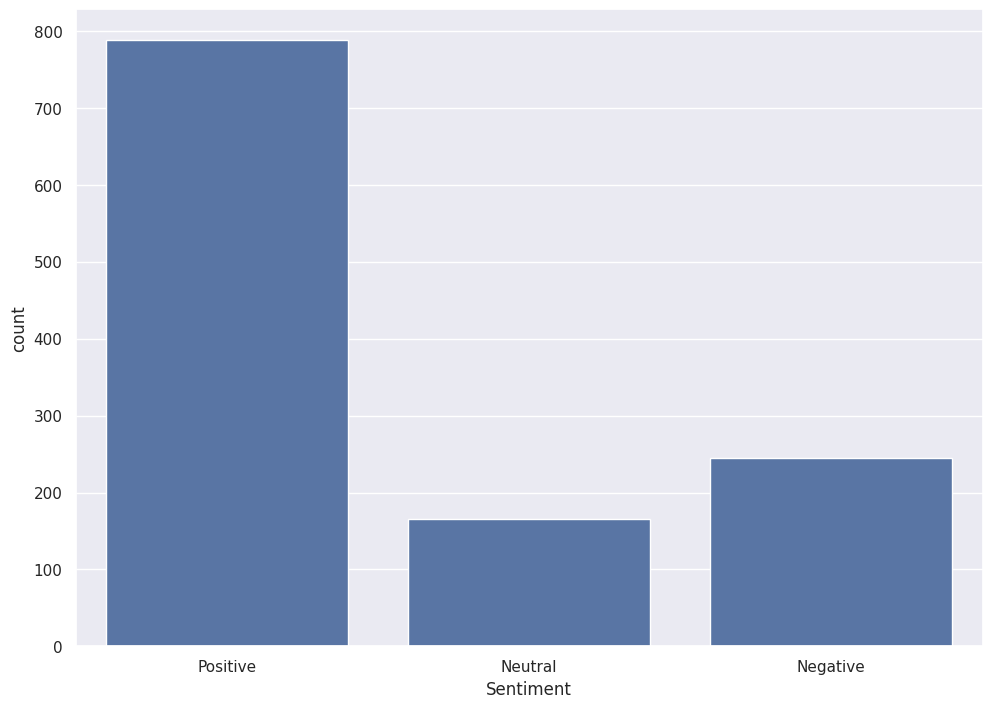

In [13]:
# Sentiment analysis visualisation
import seaborn as sns
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.countplot(x='Sentiment',data = df,order=['Positive','Neutral','Negative'])

The bar chart above shows the count of reviews in each sentiment category: Positive, Neutral, Negative.

**How to read and interpret this chart:**

- **Dominant sentiment:** The tallest bar tells you the prevailing opinion of users. For most consumer app reviews, you would expect Positive to dominate if the product is well-received, or Negative if there is a widespread issue
- **Neutral proportion:** A large Neutral bar often indicates that the TextBlob threshold (polarity = 0) is catching many reviews that are borderline — these reviews use mildly positive or mildly negative language, or are purely factual. Consider whether adjusting the threshold changes the distribution meaningfully
- **Imbalance:** If the positive-to-negative ratio is 10:1, the distribution is highly skewed. This is common for apps with self-selection bias (very satisfied and very frustrated users are most likely to leave reviews; moderate users often do not)

**Comparing against star ratings:** If your dataset also contains a numerical star rating (e.g. 1–5 stars), you can check whether the TextBlob sentiment aligns with the rating:
```python
print(df.groupby('Sentiment')['score'].mean())
```
If TextBlob is working well, positive sentiment reviews should have higher average star ratings than negative ones. A large discrepancy suggests the model may be misclassifying some reviews.


In [14]:
# finally, save the new dataframe with all the scores to the local machine.

df.to_csv('sentiment_textblob_results.csv', index=False) # save the file to google colab/drive
files.download('sentiment_textblob_results.csv') # download the file to your local machine

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The final DataFrame with original text in the `Anydo_review_new.csv` plus `Polarity`, `Subjectivity`, and `Sentiment` columns is saved as `sentiment_textblob.csv` and downloaded to your local machine. This file can be:
- Opened in Excel or Tableau for further analysis
- Imported into a dashboard or reporting tool
- Shared with colleagues or stakeholders
- Used as input for further NLP analysis (e.g. cross-tabulating sentiment with topics from LDA)


---
## 2.2 Batch Sentiment Analysis with NLTK VADER

We now repeat the batch analysis using VADER. The pipeline is structurally identical to the TextBlob pipeline, but the underlying algorithm differs in two important ways:

1. **VADER produces four scores** (compound, pos, neu, neg) rather than two
2. **VADER uses ±0.05 thresholds** for classification rather than 0

When would you prefer VADER over TextBlob?
- When analysing **short, informal text** (social media, app reviews, forum posts)
- When you need **fine-grained breakdown** of how much of the text is positive vs negative vs neutral
- When **capitalisation, punctuation intensity, and degree modifiers** carry meaningful signal in your data

Both sections load the same dataset so you can compare results directly.


### Re-loading the Dataset

We reload the raw dataset from scratch here so that the VADER section is fully independent of the TextBlob section. This is good practice and it ensures that text cleaning or column additions in Section 2.1 do not accidentally carry over and affect VADER's results.


In [15]:
# Except for doing sentiment analysis for one single sentence, it's also available for you to import a dataframe and do the sentiment analysis for the whole batch.
from google.colab import files
uploaded = files.upload()
# once you run this code, it will prompt you to select a file. You just need to "Choose a file" (any file you want to do sentiment analysis) from your laptop.

In [16]:
# once you upload the data to the cloud, you can read the data into dataframe. Remember, if you close the notebook or disconnect, you need to upload the file (run the code above) again before you read data.

import pandas as pd
data_path = 'Anydo_review_new.csv' # change the csv file name to your file name that you uploaded
df = pd.read_csv(data_path) # change the csv file name to your file name that you uploaded
df.head()

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at
0,gp:AOqpTOEcWS_b8b4P2gClKovxXAPg3il0AD0ZnGw9RxY...,Unable to use it as it won't work with my Goog...,1,13,5.7.0.20,11/01/2021 01:12
1,gp:AOqpTOEidRmDaHGYPZW21SVfBkeqTruAzg7LAmCPL2_...,I downloaded this because of the cross platfor...,1,81,5.7.0.20,22/12/2020 18:31
2,gp:AOqpTOEJfVU5Os7_8CNOu_mpy2AlDz8kFxEFMeBMnxC...,I am starting to hate this app! Every time the...,1,67,5.7.0.10,02/12/2020 15:52
3,gp:AOqpTOFSPaoOVarqwKF86e7-TPUyV6BanSXKRNFGb6G...,"Liked Any.do at first, enough that I even sign...",1,102,5.7.0.10,22/11/2020 23:42
4,gp:AOqpTOEmghRiCCy0_FYbWBSoRm2ff2hzFTbEjgQ9svu...,They made me sign up for premium just to have ...,1,2,5.7.0.20,31/12/2020 01:49


In [17]:
# set the target column to the review column

target_column = 'content'

In [18]:
# you might need to do some text cleaning before sentiment analysis. One basic requirement for running the sentiment analysis function, you need to make sure the target column has no null values.
df = df.dropna(subset = [target_column]) # Here I just delete the rows if the target column is null (in this case, it's "Review" column)

In [19]:
# first, import the package (suppose we haven't imported it yet) run the analyzer (SentimentIntensityAnalyzer())
import nltk
import numpy as np
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

# Then create new columns for your dataframe (compound, pos, neu, neg) with empty dictionary
# With for loop, we get the scores for each review and append the scores to the dictionary

Result = { 'compound':[], 'pos':[] , 'neu':[], 'neg':[] }

for review in df[target_column]:
    score = sid.polarity_scores(review)
    Result['pos'].append(score['pos'])
    Result['neu'].append(score['neu'])
    Result['neg'].append(score['neg'])
    Result['compound'].append(score['compound'])

# Once this is done, new columns are created and dictionary is transformed to the dataframe

df['compound'] = pd.DataFrame(Result)['compound']
df['pos'] = pd.DataFrame(Result)['pos']
df['neu'] = pd.DataFrame(Result)['neu']
df['neg'] = pd.DataFrame(Result)['neg']
df['sentiment'] = np.where(df['compound']>=0.05, 'Positive',np.where(df['compound']<=-0.05,'Negative', 'Neutral'))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


The above code obtains the VADER Scores and adds it to the DataFrame `df`.

Five new columns have been added:

| Column | Type | Description |
|--------|------|-------------|
| `compound` | float [-1, 1] | Overall normalised sentiment score |
| `pos` | float [0, 1] | Proportion of positive sentiment |
| `neu` | float [0, 1] | Proportion of neutral sentiment |
| `neg` | float [0, 1] | Proportion of negative sentiment |
| `sentiment` | string | 'Positive', 'Negative', or 'Neutral' label |

**Understanding the code structure:** The code iterates through each review, calls `sid.polarity_scores(review)` to get a dictionary of scores, then appends each score to a results dictionary. Finally, the results dictionary is converted into DataFrame columns. This explicit loop approach makes it easy to add custom processing inside the loop (e.g. pre-cleaning each review before scoring).

**The classification logic** applies VADER's recommended ±0.05 thresholds:
```python
compound >= +0.05  →  'Positive'
compound <= -0.05  →  'Negative'
otherwise          →  'Neutral'
```


In [20]:
# sort by polarity (low to high)
sorted_df = df.sort_values(by=['compound'])

# print top 5 positive and negative
print("Most positive #5 reviews ")
print(sorted_df[target_column].tail())
print("\n") # print line break
print("Most negative #5 reviews ")
print(sorted_df[target_column].head())

Most positive #5 reviews 
511     Great app! But have a few suggestions that wou...
258     Sorry, not Impressed I'm sorry to leave a poor...
1075    Truly the best planning app! I was looking for...
974     It's OK but it's not for me. I'm a student and...
839     It's OK but it's not for me. I'm a student and...
Name: content, dtype: object


Most negative #5 reviews 
256    It's a mess. I add new tasks and tag them. But...
505    Used to think it was a 5 star app but they kee...
169    I am starting to hate this app! Every time the...
2      I am starting to hate this app! Every time the...
897    It suddenly quit syncing. I've tried logging o...
Name: content, dtype: object


As with TextBlob, printing the most extreme reviews is a sanity check. **Compare the extreme reviews from VADER vs TextBlob:**

- Do the same reviews appear at the top and bottom of both rankings?
- If different reviews appear as most extreme, this tells you that the two models weight language differently — for example, VADER may amplify a review with `!!!` that TextBlob scores more conservatively
- Look for reviews where VADER and TextBlob strongly disagree. These are the most informative edge cases: they often involve sarcasm, irony, negation, or domain-specific vocabulary not well-covered by either lexicon


<Axes: xlabel='sentiment', ylabel='count'>

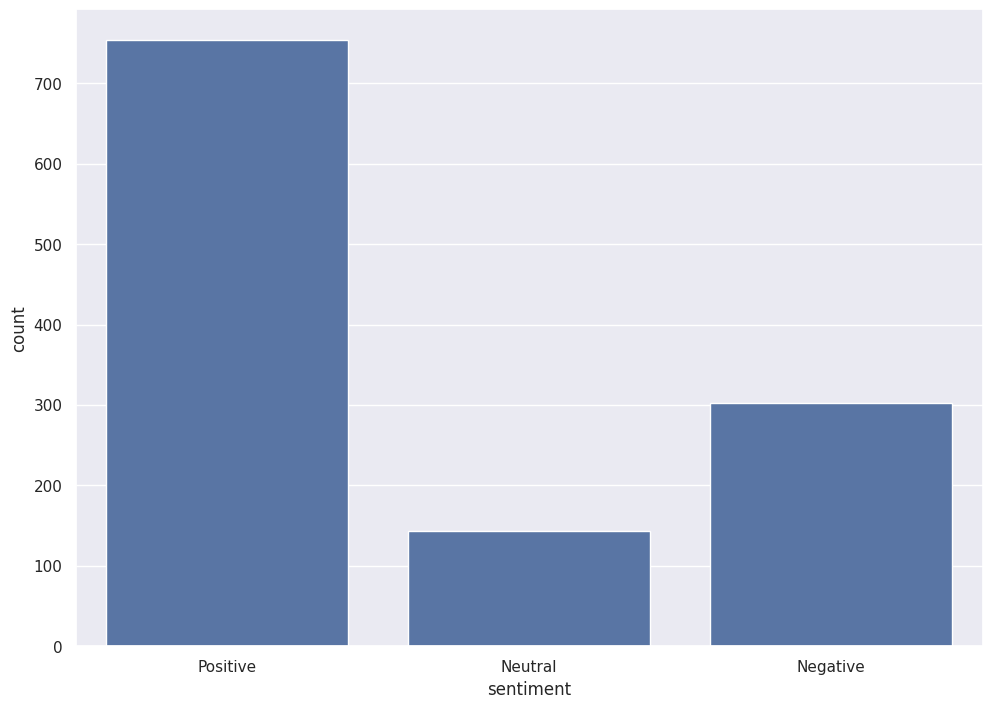

In [21]:
# Sentiment analysis visualisation
import seaborn as sns
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.countplot(x='sentiment',data = df,order=['Positive','Neutral','Negative'])

**Compare this chart with the TextBlob distribution from Section 2.1:**

- **Neutral count:** VADER typically produces a higher Neutral count than TextBlob for the same dataset. This is because VADER's ±0.05 threshold is more conservative — reviews need to exceed a minimum intensity to be classified as positive or negative. TextBlob classifies any review with polarity > 0 (even 0.001) as Positive
- **Positive vs Negative split:** The ratio may differ between the two models. If VADER classifies significantly more reviews as Negative than TextBlob, it likely means VADER is detecting negative language patterns (capitalisation, punctuation) that TextBlob's simpler averaging misses
- **Which distribution is more 'correct'?** Neither model has access to ground truth. To evaluate, compare both against the star rating column: `pd.crosstab(df['sentiment'], df['score'])`. The model whose Positive class most strongly correlates with high star ratings is performing better on this dataset

**Key insight for business reporting:** Be consistent in which tool and threshold you use across time periods when tracking sentiment trends. Switching models midway through a tracking study will create artificial shifts in the data.


In [22]:
# finally, save the new dataframe with all the scores to the local machine.

df.to_csv('sentiment_nltk_results.csv', index=False) # save the file to google drive
files.download('sentiment_nltk_results.csv') # download the file to your local machine

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The results of the VADER analysis is saved as `sentiment_nltk_results.csv`. You now have two output files:
- `sentiment_textblob_results.csv` — with Polarity, Subjectivity, and Sentiment (TextBlob)
- `sentiment_nltk_results.csv` — with compound, pos, neu, neg, and sentiment (VADER)

Both files include the original columns so results can be joined or compared in external tools.


---
# 3. Interpreting and Acting on Sentiment Results

## 3.1 The Five-Step Interpretation Framework

Getting sentiment scores is only the beginning. The real value comes from translating numbers into insight. Follow this framework:

### Step 1 — Examine the distribution
Look at the overall positive/neutral/negative breakdown. What is the prevailing opinion? What proportion of customers are dissatisfied? A business benchmark: for a well-regarded consumer product, you might expect >60% positive, <20% negative. Anything below 50% positive warrants attention.

### Step 2 — Validate against ratings
If your data has a numerical rating (e.g. 1–5 stars), cross-tabulate it against sentiment:
```python
pd.crosstab(df['Sentiment'], df['score'])
```
Sentiment analysis is **not always reliable** — especially for short reviews, sarcasm, or domain-specific language. If TextBlob classifies 4-star reviews as 'Negative', the model may be struggling with your specific domain. This validation step calibrates your trust in the output.

### Step 3 — Explore the extremes
Read actual reviews at both ends of the polarity spectrum. Ask:
- *What specific features or experiences are praised most?*
- *What specific pain points appear in the most negative reviews?*

### Step 4 — Combine with topic modelling
Sentiment tells you *how customers feel*. Topic modelling tells you *what they are talking about*. Combining the two reveals *what they feel negatively about*, which is actionable:
```python
# Example: average polarity per topic
df.groupby('topic')['Polarity'].mean().sort_values()
```
If Topic 2 (baggage handling) has a mean polarity of -0.45 while Topic 4 (cabin crew) has +0.3, you know exactly where to direct improvement efforts.

### Step 5 — Track over time
Plot sentiment trends over time to identify whether customer opinion is improving or deteriorating:
```python
df['date'] = pd.to_datetime(df['at'])
df.set_index('date')['compound'].resample('M').mean().plot()
```

## 3.2 Limitations to Bear in Mind

| Limitation | Example | Mitigation |
|-----------|---------|------------|
| **Sarcasm** | *'Oh brilliant, another crash'* scored as positive | Flag high-subjectivity, low-polarity reviews for manual review |
| **Negation scope** | *'Not at all bad'* may score as negative | Use VADER which handles negation more robustly |
| **Domain vocabulary** | *'The app killed my battery'* — 'killed' scores very negative | Build a domain-specific lexicon extension |
| **Short reviews** | *'ok'*, *'fine'* — insufficient signal | Filter out reviews below a minimum length |
| **Mixed sentiment** | *'Great features, terrible support'* | VADER's pos/neg breakdown gives more nuance than compound alone |

---

### Exercise 2 — Batch Analysis and Interpretation

1. **Threshold tuning:** In the TextBlob classification line, change the threshold from `0` to `0.1` (so only reviews with polarity > 0.1 are 'Positive'). Re-run the countplot. How does the distribution change? Which threshold do you think is more appropriate for this dataset, and why?

2. **Validate against ratings:** Run `pd.crosstab(df['Sentiment'], df['score'])`. Do reviews classified as 'Positive' tend to have higher star ratings? Is there a pattern of misclassification at any particular star level?

3. **Compare TextBlob vs VADER:** Create a comparison column `df['agreement'] = (df['Sentiment'] == df['sentiment'])` (after merging both result DataFrames on the review index). What percentage of reviews do the two models agree on? Print 5 reviews where they **disagree** — can you identify why they differ?

4. **Subjectivity analysis:** Using the TextBlob results, filter to reviews with very low subjectivity (`df[df['Subjectivity'] < 0.2]`). What kind of language do these reviews use? Are they more or less likely to be negative than highly subjective reviews?

5. **Temporal trend:** If the dataset contains a date column (`at`), parse it to datetime and plot the monthly average compound score:
   ```python
   df['date'] = pd.to_datetime(df['at'])
   monthly_sentiment = df.set_index('date')['compound'].resample('M').mean()
   monthly_sentiment.plot(title='Monthly Average VADER Compound Score', ylabel='Compound Score')
   ```
   Are there any months with unusually low sentiment? Can you link these to specific app updates or events?

6. **Apply to your own data:** Replace `'Anydo_review_new.csv'` with a CSV file containing text from a domain you are interested in (e.g. restaurant reviews, product feedback, social media posts). Change `target_column` to match your text column name. How well do the lexicon-based tools perform on your domain?
